# Data Cleaning and Preparation

* During the course of doing data analysis and modeling, a significant amount of time is spent on data preparation: **loading, cleaning, transforming, and rearranging**. 
* Such tasks are often reported to take up **80% or more of an analyst’s time**. 
* Sometimes the way that data is stored in files or databases is not in the right format for a particular task.
* pandas, along with the built-in Python language features, provides you with a high-level, flexible, and fast set of tools to enable you to manipulate data into the right form.

In [ ]:
import numpy as np
import pandas as pd
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

## Handling Missing Data

In [ ]:
# using np.nan for floating-point value NaN (Not a Number) to represent missing data 
#- sentinal value that can be easily detected
string_data = pd.Series(['aardvark', 'artichoke', np.nan, 'avocado'])
print(string_data)
string_data.isnull()

In [ ]:
# built-in Python None value is also treated as NA in object arrays
string_data[0] = None
string_data.isnull()

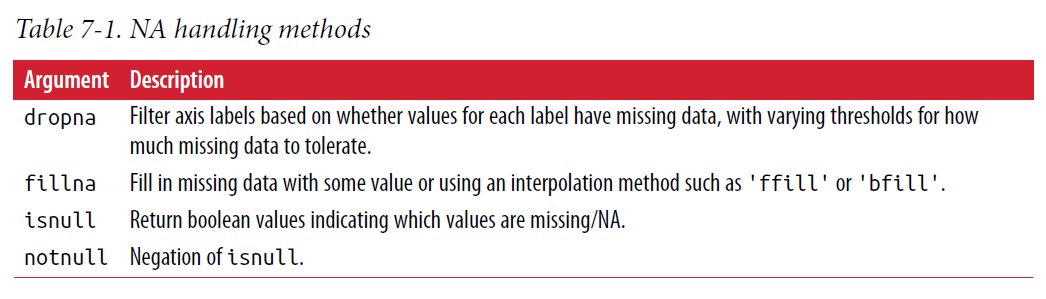

### Filtering Out Missing Data

In [ ]:
# dropna
from numpy import nan as NA
data = pd.Series([1, NA, 3.5, NA, 7])
data.dropna()

In [ ]:
# notnull
data[data.notnull()]

In [ ]:
data = pd.DataFrame([[1., 6.5, 3.], [1., NA, NA],
                     [NA, NA, NA], [NA, 6.5, 3.]])
cleaned = data.dropna()
print(data)
print(cleaned) # by by default drops any row containing a missing value:

In [ ]:
data.dropna(how='all') # only drop rows that are all NA

In [ ]:
data[4] = NA
data
data.dropna(axis=1, how='all') # To drop columns that are all NA

In [ ]:
df = pd.DataFrame(np.random.randn(7, 3))
df.iloc[:4, 1] = NA
df.iloc[:2, 2] = NA
print(df)
print(df.dropna())
df.dropna(thresh=2) # keep only rows containing a certain number of observations

### Filling In Missing Data

In [ ]:
df.fillna(0)

In [ ]:
df.fillna({1: 0.5, 2: 0}) # use a different fill value for each column

In [ ]:
_ = df.fillna(0, inplace=True) # modify the existing object in-place
df

In [ ]:
df = pd.DataFrame(np.random.randn(6, 3))
df.iloc[2:, 1] = NA
df.iloc[4:, 2] = NA
print(df) 


In [ ]:
df.fillna?
df.fillna(method='ffill') # propagate last valid observation forward to next valid


In [ ]:
df.fillna?
df.fillna(method='ffill', limit=2) # the maximum number of consecutive NaN values to forward/backward fill

In [ ]:
data = pd.Series([1., NA, 3.5, NA, 7])
data.fillna(data.mean())

## Data Transformation

### Removing Duplicates

In [ ]:
data = pd.DataFrame({'k1': ['one', 'two'] * 3 + ['two'],
                     'k2': [1, 1, 2, 3, 3, 4, 4]})
data

In [ ]:
data.duplicated() # returns a boolean Series indicating whether each row is a duplicate

In [ ]:
data.drop_duplicates() # 

In [ ]:
data['v1'] = range(7)
print(data)
data.drop_duplicates(['k1']) # filter duplicates only based on the 'k1' column

In [ ]:
data.drop_duplicates?
data.drop_duplicates(['k1', 'k2'], keep='last') # by default keep the first observed value combination. 
#Passing keep='last' will return the last one:

### Transforming Data Using a Function or Mapping

In [ ]:
data = pd.DataFrame({'food': ['bacon', 'pulled pork', 'bacon',
                              'Pastrami', 'corned beef', 'Bacon',
                              'pastrami', 'honey ham', 'nova lox'],
                     'ounces': [4, 3, 12, 6, 7.5, 8, 3, 5, 6]})
data

In [ ]:
# add a column indicating the type of animal that each food came from
meat_to_animal = {
  'bacon': 'pig',
  'pulled pork': 'pig',
  'pastrami': 'cow',
  'corned beef': 'cow',
  'honey ham': 'pig',
  'nova lox': 'salmon'
}

In [ ]:
lowercased = data['food'].str.lower()
lowercased


In [ ]:
data['animal'] = lowercased.map(meat_to_animal) # map1: accept dict containing a mapping - to modify a subset of values
data

In [ ]:
data['food'].map(lambda x: meat_to_animal[x.lower()]) # map use case 2: accept function

### Replacing Values

In [ ]:
data = pd.Series([1., -999., 2., -999., -1000., 3.])
data

In [ ]:
data.replace(-999, np.nan) # -999 values might be sentinel values

In [ ]:
data.replace([-999, -1000], np.nan) # replace multiple values at once

In [ ]:
data.replace([-999, -1000], [np.nan, 0]) # use a different replacement for each value

In [ ]:
data.replace({-999: np.nan, -1000: 0}) # argument be a dict

### Renaming Axis Indexes

In [ ]:
data = pd.DataFrame(np.arange(12).reshape((3, 4)),
                    index=['Ohio', 'Colorado', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
data

In [ ]:
transform = lambda x: x[:4].upper()
data.index.map(transform) # data.index is a Series, has map function.

In [ ]:
data.index = data.index.map(transform)
data

In [ ]:
data.rename(index=str.title, columns=str.upper) 
# create a transformed version of a dataset without modifying the original, a useful method is rename

In [ ]:
data.rename(index={'OHIO': 'INDIANA'},
            columns={'three': 'peekaboo'}) 
#rename in conjunction with a dict-like object providing new name for a subset of axis labels

In [ ]:
data.rename(index={'OHIO': 'INDIANA'}, inplace=True)
data

### Discretization and Binning

Continuous data is often discretized or otherwise separated into “bins” for analysis.

Suppose you have data about a group of people in a study, and you want to group
them into discrete age buckets:

In [ ]:
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]

In [ ]:
#divide these into bins of 18 to 25, 26 to 35, 36 to 60, and finally 61 and older.
bins = [18, 25, 35, 60, 100]
cats = pd.cut(ages, bins) # categorical
cats

In [ ]:
cats.codes # The category codes of this categorical


In [ ]:
cats.categories # The categories of this categorical.


In [ ]:
pd.value_counts(cats) #the bin counts for the result

In [ ]:
pd.cut(ages, [18, 26, 36, 61, 100], right=False) # change which side is closed by passing value to right argument

In [ ]:
group_names = ['Youth', 'YoungAdult', 'MiddleAged', 'Senior']
pd.cut(ages, bins, labels=group_names) # pass your own bin names by passing a list or array to the labels option

In [ ]:
# pass an integer number of bins to cut instead of explicit bin edges, it will compute
# equal-length bins based on the minimum and maximum values in the data.
data = np.random.rand(20)
pd.cut(data, 4, precision=2)  # precision = 2 limits the decimal precision to two digits

In [ ]:
data = np.random.randn(1000)  # Normally distributed
cats = pd.qcut(data, 4)  # Cut into quartiles - you will obtain roughly equal-size bins
cats
pd.value_counts(cats)

In [ ]:
cats = pd.qcut(data, [0, 0.1, 0.5, 0.9, 1.]) # you can pass your own quantiles (numbers between 0 and 1, inclusive):

In [ ]:
pd.value_counts(cats)

### Detecting and Filtering Outliers

Suppose you wanted to find values in one of the columns exceeding 3 in absolute value:

In [ ]:
data = pd.DataFrame(np.random.randn(1000, 4))
data.describe()

In [ ]:
col = data[2]
col[np.abs(col) > 3] #  to find values in one of column '2' exceeding 3 in absolute value

In [ ]:
data[(np.abs(data) > 3).any(1)] # to find rows having a value  exceeding 3 in absolute value

In [ ]:
data[np.abs(data) > 3] = np.sign(data) * 3 # Values can be set based on these criteria
data.describe()

In [ ]:
np.sign(data).head() 
# produces 1 and –1 values based on whether the values
# in data are positive or negative:

### Permutation and Random Sampling

In [ ]:
# permutation: randomly reordering the rows in a dataframe

In [ ]:
df = pd.DataFrame(np.arange(5 * 4).reshape((5, 4)))
df

In [ ]:
sampler = np.random.permutation(5)
sampler

In [ ]:
df.take(sampler)

In [ ]:
# To select a random subset without replacement
df.sample(n=3)

In [ ]:
choices = pd.Series([5, 7, -1, 6, 4])
draws = choices.sample(n=10, replace=True) # with replacement
draws

### Computing Indicator/Dummy Variables

converting a categorical variable into a **“dummy” or “indicator”** matrix

If a
column in a DataFrame has **k** distinct values, you would derive a matrix or Data‐
Frame with **k** columns containing all 1s and 0s

In [ ]:
df = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'b'],
                   'data1': range(6)})
df

In [ ]:
pd.get_dummies(df['key'])

In [ ]:
dummies = pd.get_dummies(df['key'], prefix='key') #add a prefix to the columns in the indicator 
dummies

In [ ]:
df_with_dummy = df[['data1']].join(dummies)
df_with_dummy

In [ ]:
# a more complicated example with movielen dataset

In [ ]:
mnames = ['movie_id', 'title', 'genres']
movies = pd.read_table('datasets/movielens/movies.dat', sep='::',
                       header=None, names=mnames)
movies[:10]

In [ ]:
# extract the list of unique genres
all_genres = [] 
for x in movies.genres:
    all_genres.extend(x.split('|'))
genres = pd.unique(all_genres)

In [ ]:
genres

In [ ]:
 # create indicator method 1:to start with a DataFrame of all zeros, and then fill in 1s
zero_matrix = np.zeros((len(movies), len(genres)))
dummies = pd.DataFrame(zero_matrix, columns=genres)
dummies

In [ ]:
gen = movies.genres[0]
gen.split('|')


In [ ]:
dummies.columns.get_indexer(gen.split('|')) # get indexer of column names

In [ ]:
for i, gen in enumerate(movies.genres): # movie index 
    indices = dummies.columns.get_indexer(gen.split('|'))
    dummies.iloc[i, indices] = 1 # to set values based on these indices

In [ ]:
movies_windic = movies.join(dummies.add_prefix('Genre_'))
movies_windic.iloc[0]

In [ ]:
# A useful recipe for statistical applications is to combine get_dummies with a discretization
# function like cut:

np.random.seed(12345)
values = np.random.rand(10)
values
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
pd.get_dummies(pd.cut(values, bins))

## String Manipulation

### String Object Methods
ease of use for string and text processing

In [ ]:
val = 'a,b,  guido'
val.split(',') # a comma-separated string can be broken into pieces

In [ ]:
pieces = [x.strip() for x in val.split(',')] # strip to trim whitespace
pieces

In [ ]:
first, second, third = pieces  # substrings could be concatenated together with a two-colon delimiter
first + '::' + second + '::' + third

In [ ]:
'::'.join(pieces) # A faster and more Pythonic way

In [ ]:
val

In [ ]:
'guido' in val


In [ ]:
val.index(',')


In [ ]:
val.find(':')

In [ ]:
val.index(':')

In [ ]:
val.count(',')

In [ ]:
val.replace(',', '::')
val.replace(',', '')

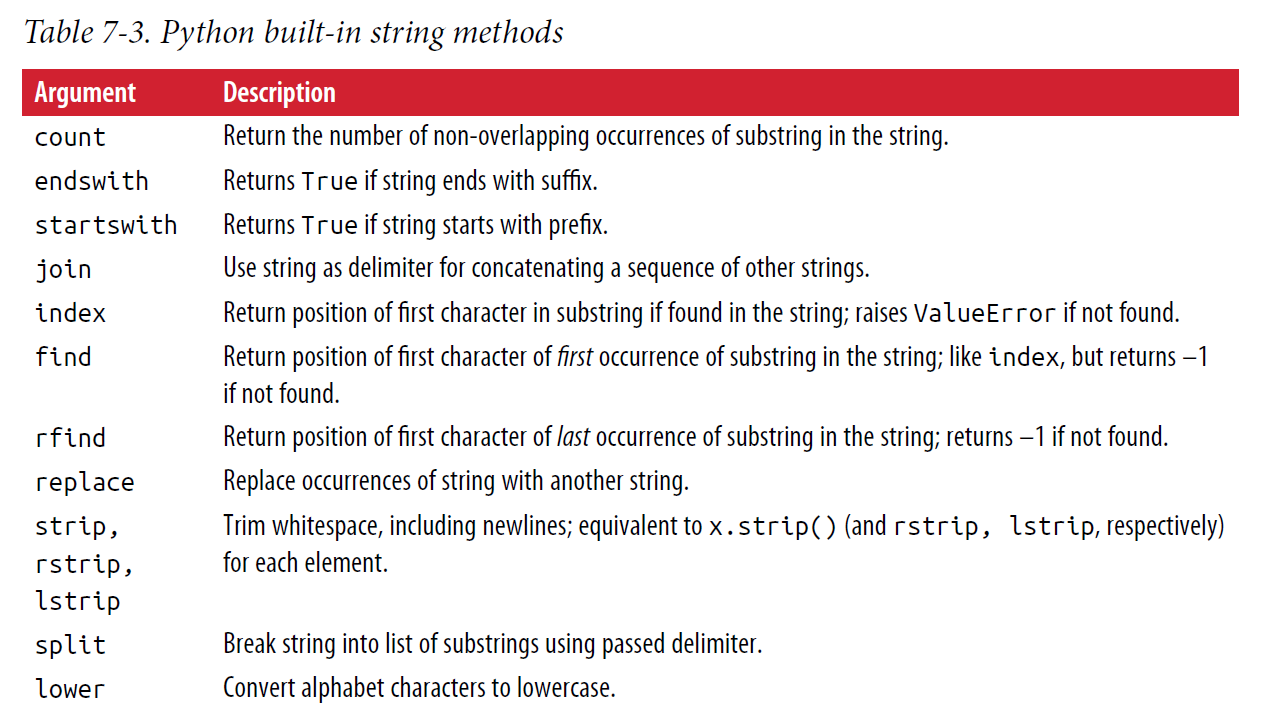

### Regular Expressions

Regular expressions provide a flexible way to search or match (often more complex)
string patterns in text. 

A single expression, commonly called a regex, is a string
formed according to the regular expression language. 

Python’s built-in **re** module is
responsible for applying regular expressions to strings

The re module functions fall into three categories: **pattern matching, substitution,
and splitting**

In [ ]:
# split a string with a variable number of whitespace characters (tabs, spaces, and newlines) 
import re
text = "foo    bar\t baz  \tqux"
re.split('\s+', text) # '\s+':regex - describing one or more whitespace characters

In [ ]:
# two steps in above code 
regex = re.compile('\s+') # compile a regular expression and then reuse it. 
regex.split(text)

In [ ]:
regex.findall(text) # get a list of all patterns matching the regex

In [ ]:
text = """Dave dave@google.com
Steve steve@gmail.com
Rob rob@gmail.com
Ryan ryan@yahoo.com
"""
pattern = r'[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,4}' # capable of identifying most email addresses  {2,4} match 2-4 charactores

# https://docs.python.org/3/library/re.html 

# re.IGNORECASE makes the regex case-insensitive
regex = re.compile(pattern, flags=re.IGNORECASE) 

In [ ]:
regex.findall(text)

In [ ]:
regex.findall(None)

In [ ]:
regex.findall(np.nan)

In [ ]:
m = regex.search(text)
m
text[m.start():m.end()] # start and end position of the pattern in the string. 

In [ ]:
m.start(),m.end()
m

In [ ]:
print(regex.match(text))# t only will match if the pattern occurs at the start of the string:

In [ ]:
print(regex.sub('REDACTED', text)) # eturn a new string with occurrences of the pattern replaced by the a new string

In [ ]:
pattern = r'([A-Z0-9._%+-]+)@([A-Z0-9.-]+)\.([A-Z]{2,4})' # put parentheses around the parts of the pattern
# to segment regex into three segments username, domain name, domain suffix. 
regex = re.compile(pattern, flags=re.IGNORECASE) 

In [ ]:
m = regex.match('wesm@bright.net')
m.groups() #  returns a tuple of the pattern components with its groups

In [ ]:
regex.findall(text)

In [ ]:
# sub also has access to groups in each match using special symbols like \1 and \2. The
# symbol \1 corresponds to the first matched group, \2 corresponds to the second, and
# so forth
print(regex.sub(r'Username: \1, Domain: \2, Suffix: \3', text)) # r - raw string

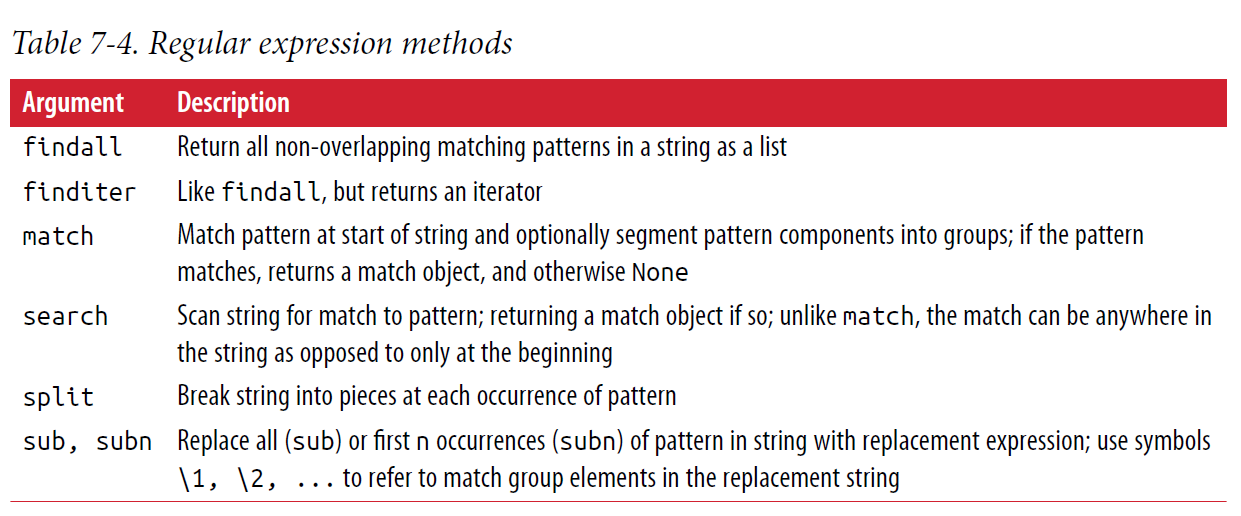

### Vectorized String Functions in pandas

In [ ]:
data = {'Dave': 'dave@google.com', 'Steve': 'steve@gmail.com',
        'Rob': 'rob@gmail.com', 'Wes': np.nan}
data = pd.Series(data)
data


In [ ]:
data.isnull()

Series has array-oriented methods for string operations that **skip NA values**. 

These are accessed through Series’s **str** attribute data.str.contains('gmail')

In [ ]:
pattern

In [ ]:
data.str.findall(pattern, flags=re.IGNORECASE)

In [ ]:
# vectorized element retrieval
matches = data.str.match(pattern, flags=re.IGNORECASE)
matches

In [ ]:
data.str.get(1)


In [ ]:
data.str[0]

In [ ]:
data.str[:5] # slice strings 

## Conclusion